In [ ]:
# Superstore Sales Analysis

## Project Objective

Analyze Superstore sales data to discover business insights, identify sales trends,
understand customer behavior, and provide recommendations to improve profitability.

In [ ]:
import pandas as pd 
import numpy as np 


import matplotlib.pyplot as plt
import seaborn as sns


import warings 
warings.filterwarings("ingore")

plt.style.use("ggplot")
pd.set_option("display.max_columns",None)

In [5]:
df = pd.read_csv(r"C:\Users\m.rooney\Downloads\sample_-_superstore.csv")

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [8]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.shape

(10194, 21)

In [10]:
df.describe(include="object")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
count,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194
unique,5111,1242,1338,4,804,800,3,2,542,59,654,4,1862,3,17,1849
top,US-2026-100111,09/05/2025,12/16/2024,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,10035,West,FUR-FU-10004270,Office Supplies,Binders,Staples
freq,14,38,38,6120,41,41,5281,9994,915,2001,263,3253,20,6128,1548,50


In [11]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date "] = pd.to_datetime(df["Ship Date"])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  object        
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [16]:
list(df.columns)

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Ship Date ']

In [18]:
df = df.loc[:, ~df.columns.duplicated()]

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  object        
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [23]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Ship Date ']

In [24]:
for i, col in enumerate(df.columns):
    print(i, col)

0 Row ID
1 Order ID
2 Order Date
3 Ship Date
4 Ship Mode
5 Customer ID
6 Customer Name
7 Segment
8 Country/Region
9 City
10 State/Province
11 Postal Code
12 Region
13 Product ID
14 Category
15 Sub-Category
16 Product Name
17 Sales
18 Quantity
19 Discount
20 Profit
21 Ship Date 


In [25]:
df.iloc[:, [3, 21]].head()

,Ship Date,Ship Date
0,01/07/2023,2023-01-07
1,01/08/2023,2023-01-08
2,01/08/2023,2023-01-08
3,01/08/2023,2023-01-08
4,01/12/2023,2023-01-12


In [27]:
df.iloc[0]

Row ID                                                            1
Order ID                                             US-2023-103800
Order Date                                      2023-01-03 00:00:00
Ship Date                                                01/07/2023
Ship Mode                                            Standard Class
Customer ID                                                DP-13000
Customer Name                                         Darren Powers
Segment                                                    Consumer
Country/Region                                        United States
City                                                        Houston
State/Province                                                Texas
Postal Code                                                   77095
Region                                                      Central
Product ID                                          OFF-PA-10000174
Category                                        

In [32]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Month_Number"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [33]:
df["Sales"].sum()

np.float64(2326534.3543)

In [35]:
df["Profit"].sum()

np.float64(292296.8146)

In [36]:
df["Sales"].mean()

np.float64(228.22585386501862)

In [38]:
df["Profit"].mean()

np.float64(28.673417166960956)

In [40]:
df["Order ID"].nunique()

5111

In [41]:
df["Customer ID"].nunique()

804

In [43]:
df["Product Name"].nunique()

1849

In [45]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

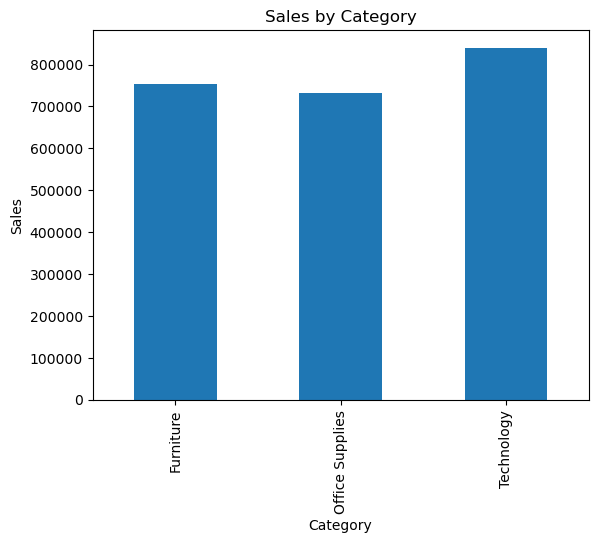

In [47]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [49]:
sub = df.groupby("Sub-Category")["Sales"].sum().sort_values()

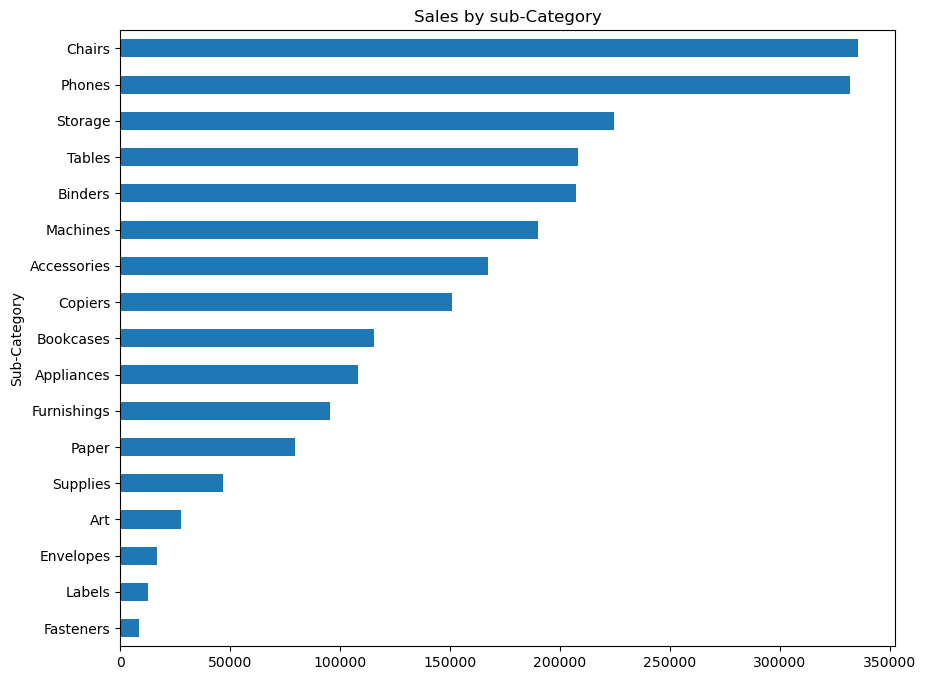

In [50]:
sub.plot(kind="barh" , figsize=(10,8))
plt.title("Sales by sub-Category")
plt.show()

In [52]:
profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()

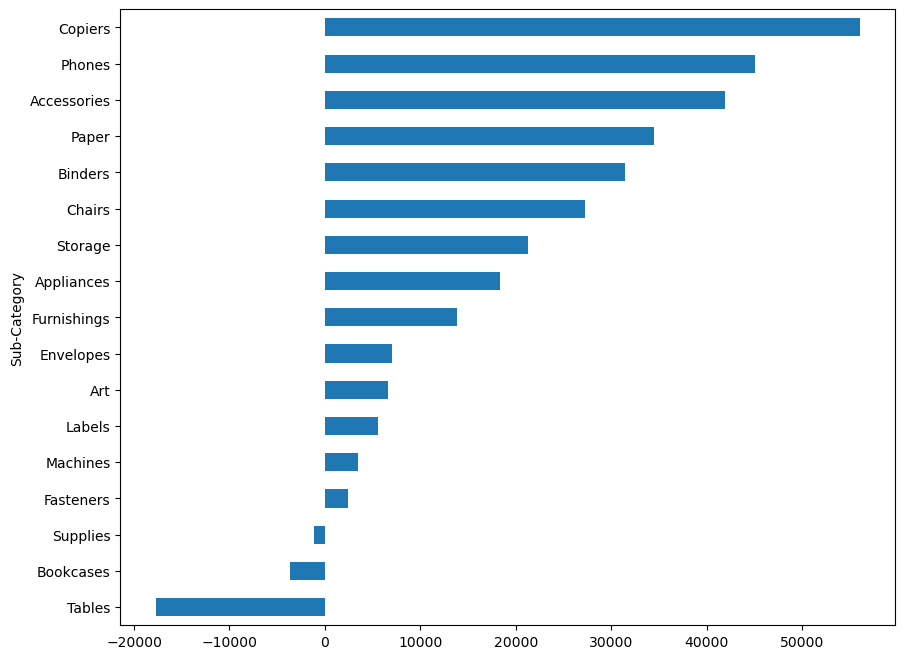

In [53]:
profit.plot(kind = "barh", figsize=(10,8))
plt.show()

In [56]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

<Axes: ylabel='Product Name'>

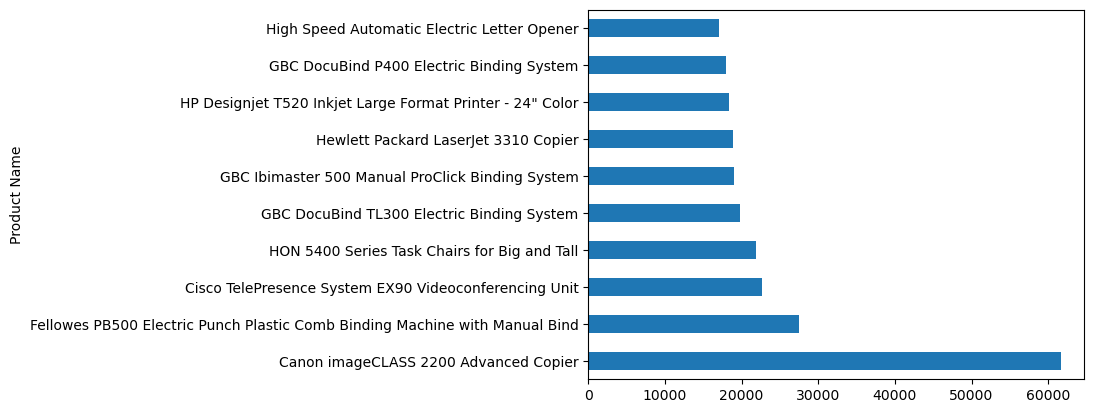

In [58]:
top_products.plot(kind="barh")

In [60]:
cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False)

<Axes: xlabel='City'>

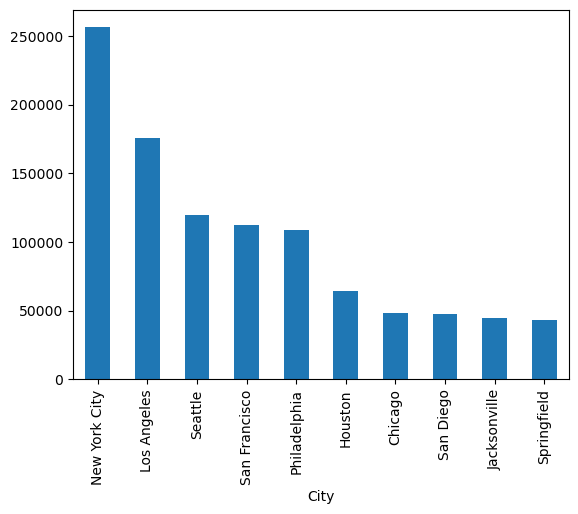

In [61]:
cities.head(10).plot(kind = "bar")

In [66]:
region = df.groupby("Region")[["Sales","Profit"]].sum()

In [68]:
segment = df.groupby("Segment")["Sales"].sum()

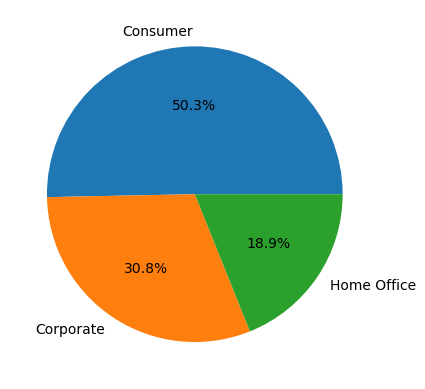

In [70]:
segment.plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.show()

In [71]:
ship = df.groupby("Ship Mode")["Sales"].sum()

<Axes: xlabel='Ship Mode'>

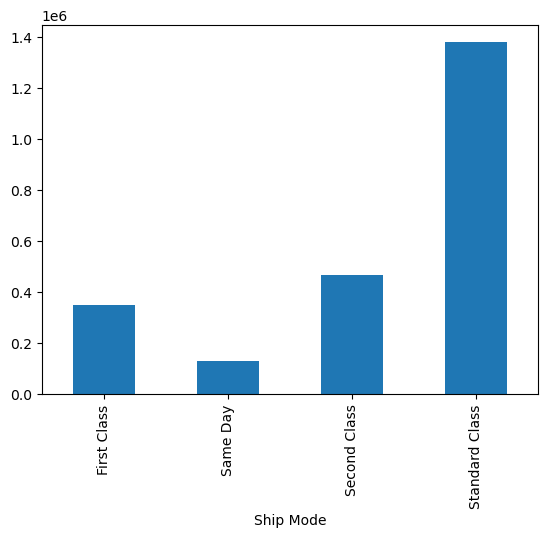

In [72]:
ship.plot(kind="bar")

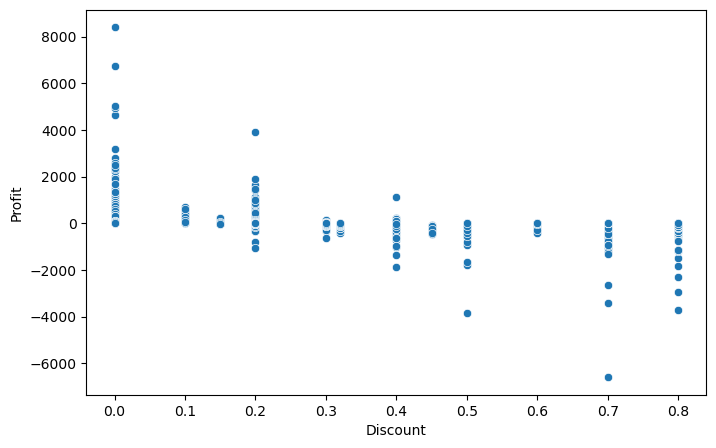

In [73]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="Discount",
                y="Profit")

plt.show()

In [75]:
corr = df[["Sales","Quantity","Discount","Profit"]].corr()

<Axes: >

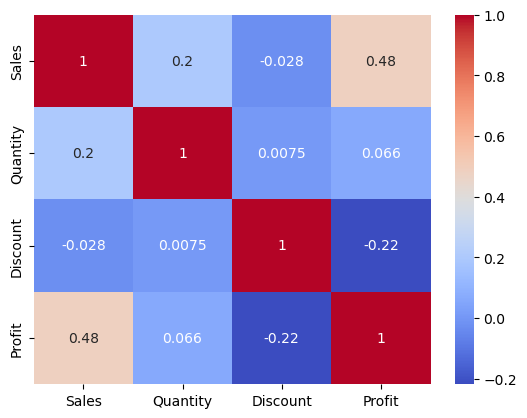

In [78]:
sns.heatmap( corr,
             annot=True,
             cmap= "coolwarm")

In [79]:
monthly = df.groupby("Month_Number")["Sales"].sum()

<Axes: xlabel='Month_Number'>

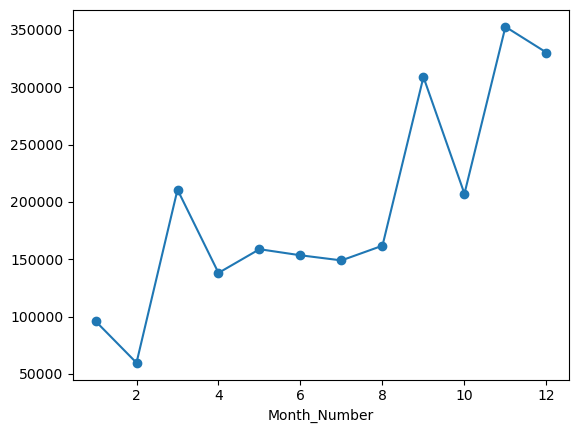

In [81]:
monthly.plot(marker="o")

In [83]:
monthly_profit = df.groupby("Month_Number")["Profit"].sum()

<Axes: xlabel='Month_Number'>

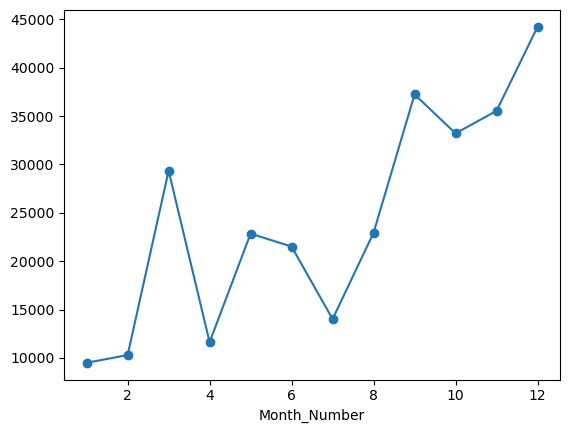

In [84]:
monthly_profit.plot(marker="o")

In [86]:
yearly = df.groupby("Year")[["Sales","Profit"]].sum()

<Axes: xlabel='Year'>

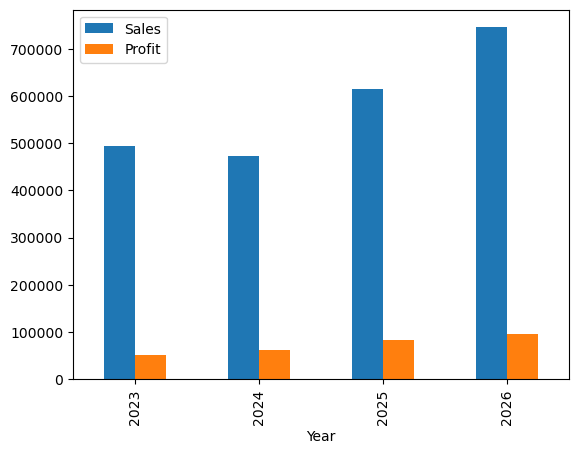

In [87]:
yearly.plot(kind="bar")

<Axes: xlabel='Sales', ylabel='Count'>

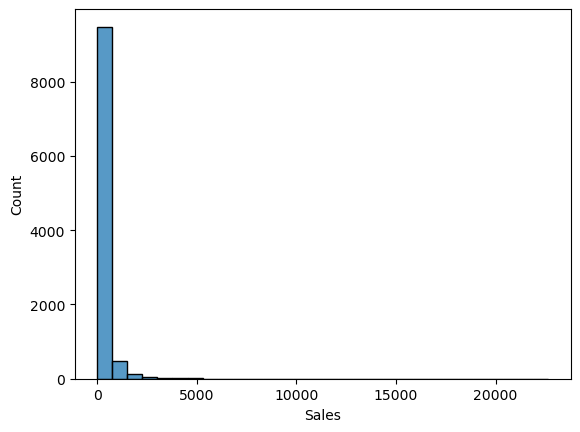

In [88]:
sns.histplot(df["Sales"],bins=30)

<Axes: xlabel='Sales'>

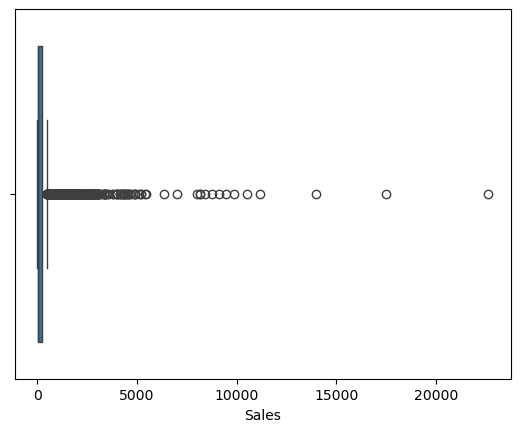

In [90]:
sns.boxplot(x=df["Sales"])

In [91]:
loss = df.groupby("Product Name")["Profit"].sum().sort_values().head(10)

<Axes: ylabel='Product Name'>

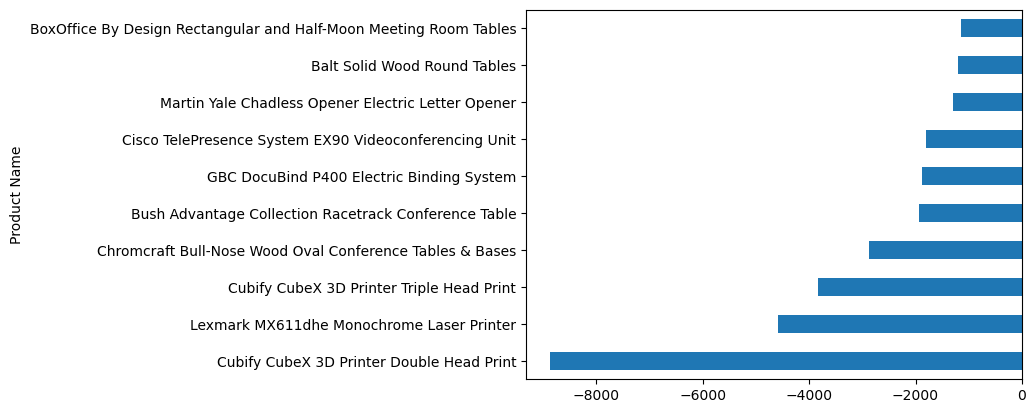

In [92]:
loss.plot(kind="barh")

In [93]:
profit = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

<Axes: ylabel='Product Name'>

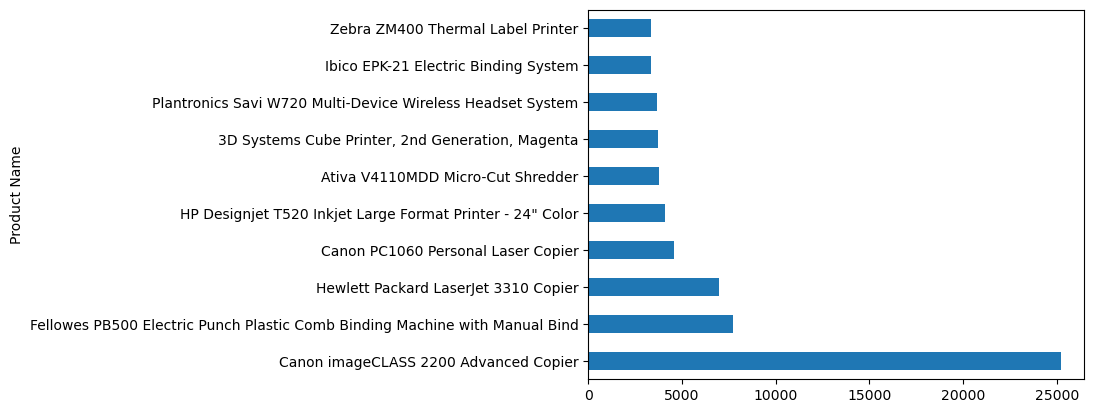

In [94]:
profit.plot(kind="barh")